In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("../data/raw/islamabad_pm25_historical.csv")
df.columns=df.columns.str.strip()
df['date']=pd.to_datetime(df['date'])
df=df.sort_values('date').reset_index(drop=True)
df.head()

,date,pm25
0,2019-04-28,162
1,2019-04-29,124
2,2019-04-30,89
3,2019-05-01,87
4,2019-05-02,69


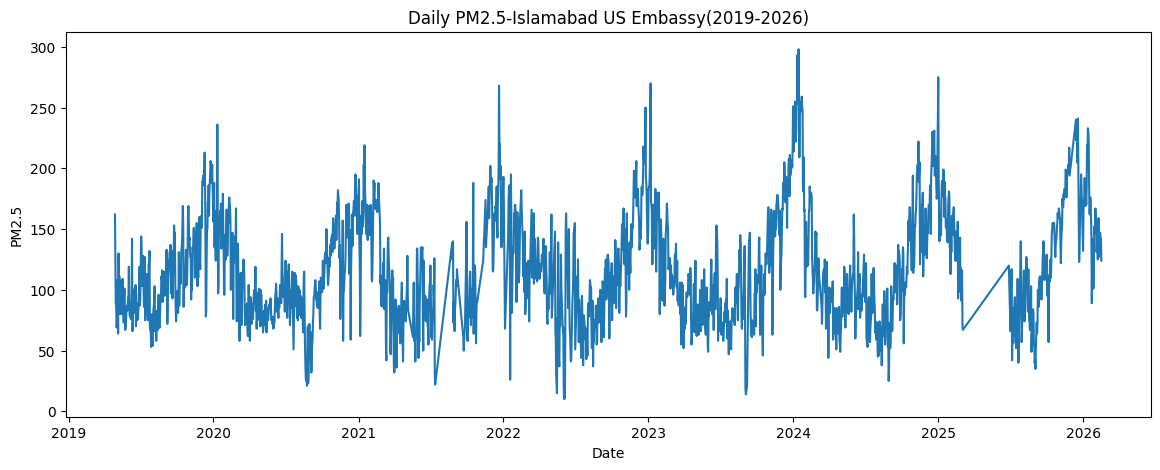

In [6]:
plt.figure(figsize=(14,5))
plt.plot(df['date'],df['pm25'])
plt.title('Daily PM2.5-Islamabad US Embassy(2019-2026)')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

In [7]:
full_range=pd.date_range(df['date'].min(),df['date'].max(),freq='D')
missing_dates=full_range.difference(df['date'])
print(f"Missing days:{len(missing_dates)}")
print(missing_dates)

Missing days:283
DatetimeIndex(['2019-05-05', '2019-12-30', '2019-12-31', '2021-04-17',
               '2021-04-18', '2021-04-19', '2021-05-07', '2021-05-08',
               '2021-05-09', '2021-05-10',
               ...
               '2025-12-07', '2025-12-08', '2025-12-09', '2025-12-10',
               '2025-12-11', '2025-12-12', '2025-12-13', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=283, freq=None)


In [8]:
df=df.set_index('date').reindex(full_range)
df['pm25']=df['pm25'].interpolate(method='linear',limit=3) 
df=df.reset_index().rename(columns={'index':'date'})
print("Remaining missing after interpolation:",df['pm25'].isna().sum())

Remaining missing after interpolation: 211


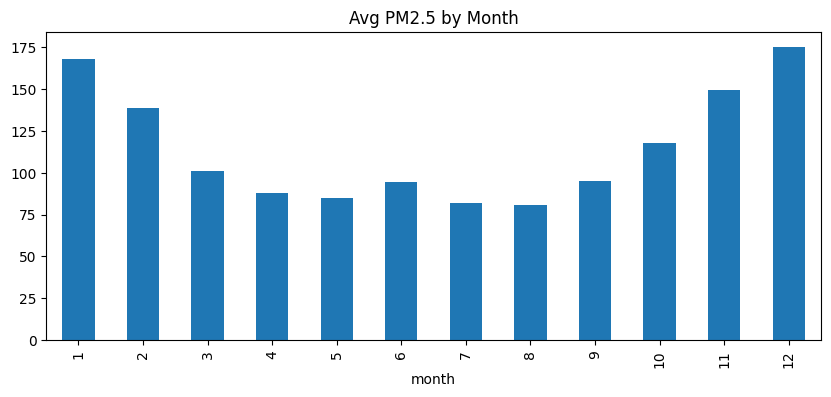

In [9]:
df['month']=df['date'].dt.month
df.groupby('month')['pm25'].mean().plot(kind='bar',figsize=(10,4),title='Avg PM2.5 by Month')
plt.show()

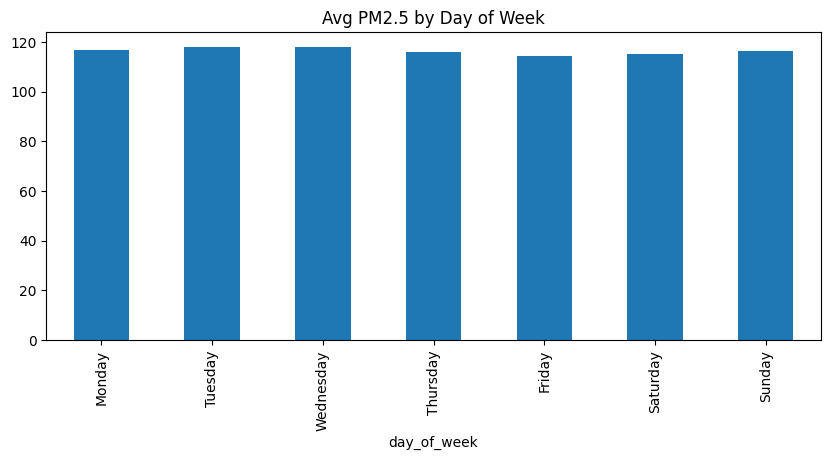

In [10]:
df['day_of_week']=df['date'].dt.day_name()
df.groupby('day_of_week')['pm25'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar',figsize=(10,4),title='Avg PM2.5 by Day of Week')
plt.show()